In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Neuron Parameters

dt = 0.1
T = 200
tau = 10.0
V_rest = -65.0
V_th = -50.0
V_reset = -65.0
R = 10.0
Time = np.arange(0, T, dt)

def simulate(I, t_ref = 0):
    I = np.ones(len(Time)) * I
    V = np.zeros(len(Time))
    V[0] = V_rest
    spike_times = []
    last_spike = -1000

    for t in range(1, len(Time)):
        if Time[t] - last_spike < t_ref:
            V[t] = V_reset
            continue
        dVdt = (-(V[t-1] - V_rest) + R*I[t]) / tau
        V[t] = V[t-1] + dVdt * dt
        if V[t] >= V_th:
            spike_times.append(Time[t])
            V[t] = V_reset
            last_spike = Time[t]
    return V, spike_times



11 [np.float64(50.1), np.float64(63.900000000000006), np.float64(77.7), np.float64(91.5), np.float64(105.30000000000001), np.float64(119.10000000000001), np.float64(132.9), np.float64(146.70000000000002), np.float64(160.5), np.float64(174.3), np.float64(188.10000000000002)]


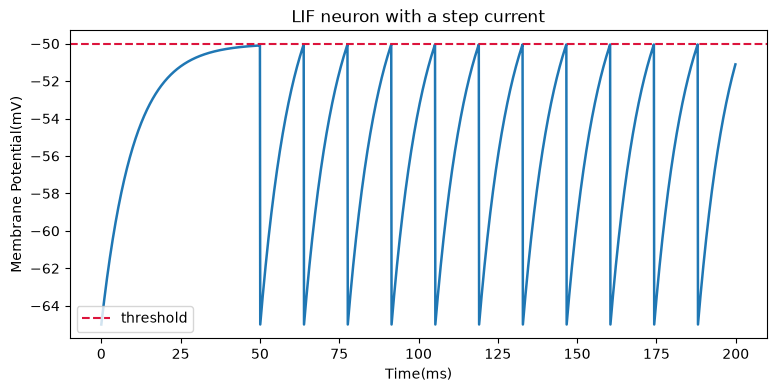

In [18]:
I_step = np.where(Time < 50, 1.5, 2.0)
V, spikes = simulate(I_step)

plt.figure(figsize = (9, 4))
plt.plot(Time, V, color ="#1f77b4", lw = 1.8)
plt.axhline(V_th, color="crimson", ls ="--", label = "threshold")
plt.xlabel("Time(ms)")
plt.ylabel("Membrane Potential(mV)")
plt.title("LIF neuron with a step current")
plt.legend()
plt.savefig("2.figures/voltage_trace.png", dpi = 300, bbox_inches = "tight")
print(len(spikes), spikes)

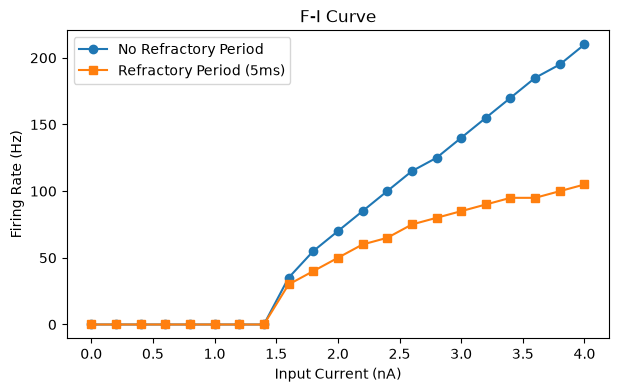

In [27]:
currents = np.arange(0, 4.1, 0.2)
rates = []
rates_ref = []

for I in currents:
    _, s = simulate(I)
    _, s_ref = simulate(I, t_ref = 5)
    rates.append(len(s) / (T / 1000))
    rates_ref.append(len(s_ref) / (T / 1000))

plt.figure(figsize = (7, 4))
plt.plot(currents, rates, "o-", label = "No Refractory Period")
plt.plot(currents, rates_ref, "s-", label = "Refractory Period (5ms)")
plt.xlabel("Input Current (nA)")
plt.ylabel("Firing Rate (Hz)")
plt.title("F-I Curve")
plt.legend()
plt.savefig("2.figures/fi_curve.png", dpi=300, bbox_inches="tight")
plt.show()